In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import shap
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 10000

In [3]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])
np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x, le=le, mc=mc):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values
feature_names = np.array(feature_cols)

print(f"    总样本: {len(X):,}  VIVO: {y.sum():,} ({y.mean()*100:.2f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr_imp = imputer.fit_transform(X_tr)
X_te_imp = imputer.transform(X_te)
X_tr_final = scaler.fit_transform(X_tr_imp)
X_te_final = scaler.transform(X_te_imp)


[0] 加载数据...
    总样本: 10,000  VIVO: 4,123.0 (41.23%)


In [4]:
print("\n[1] 训练 Random Forest + SHAP...")
model = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_tr_final, y_tr)
auc = roc_auc_score(y_te, model.predict_proba(X_te_final)[:, 1])
print(f"    RF AUC = {auc:.4f}")

n_shap = 500
X_shap = X_te_final[:n_shap]
y_shap = y_te[:n_shap]

explainer = shap.TreeExplainer(model)
sv_full = explainer.shap_values(X_shap)
if isinstance(sv_full, list):
    sv = sv_full[1]
else:
    sv = sv_full
    if sv.ndim == 3:
        sv = sv[:, :, 1]

shap_importance = np.abs(sv).mean(0)
feature_order = np.argsort(shap_importance)[::-1]
print(f"    特征排名: {[feature_names[i] for i in feature_order]}")
print(f"    Mean |SHAP|: {[f'{shap_importance[i]:.4f}' for i in feature_order]}")


[1] 训练 Random Forest + SHAP...
    RF AUC = 0.9104
    特征排名: [np.str_('Diagnostic.means'), np.str_('year'), np.str_('Raca.Color'), np.str_('Extension'), np.str_('Code.Profession'), np.str_('Age')]
    Mean |SHAP|: ['0.2421', '0.1274', '0.0421', '0.0330', '0.0287', '0.0280']


In [5]:
top_n = 6
top6_idx = feature_order[:top_n]


[2] 生成带分布的 SHAP 依赖图 (2×3 网格)
  [图] 18a_shap_dependence_with_distribution.png 已保存


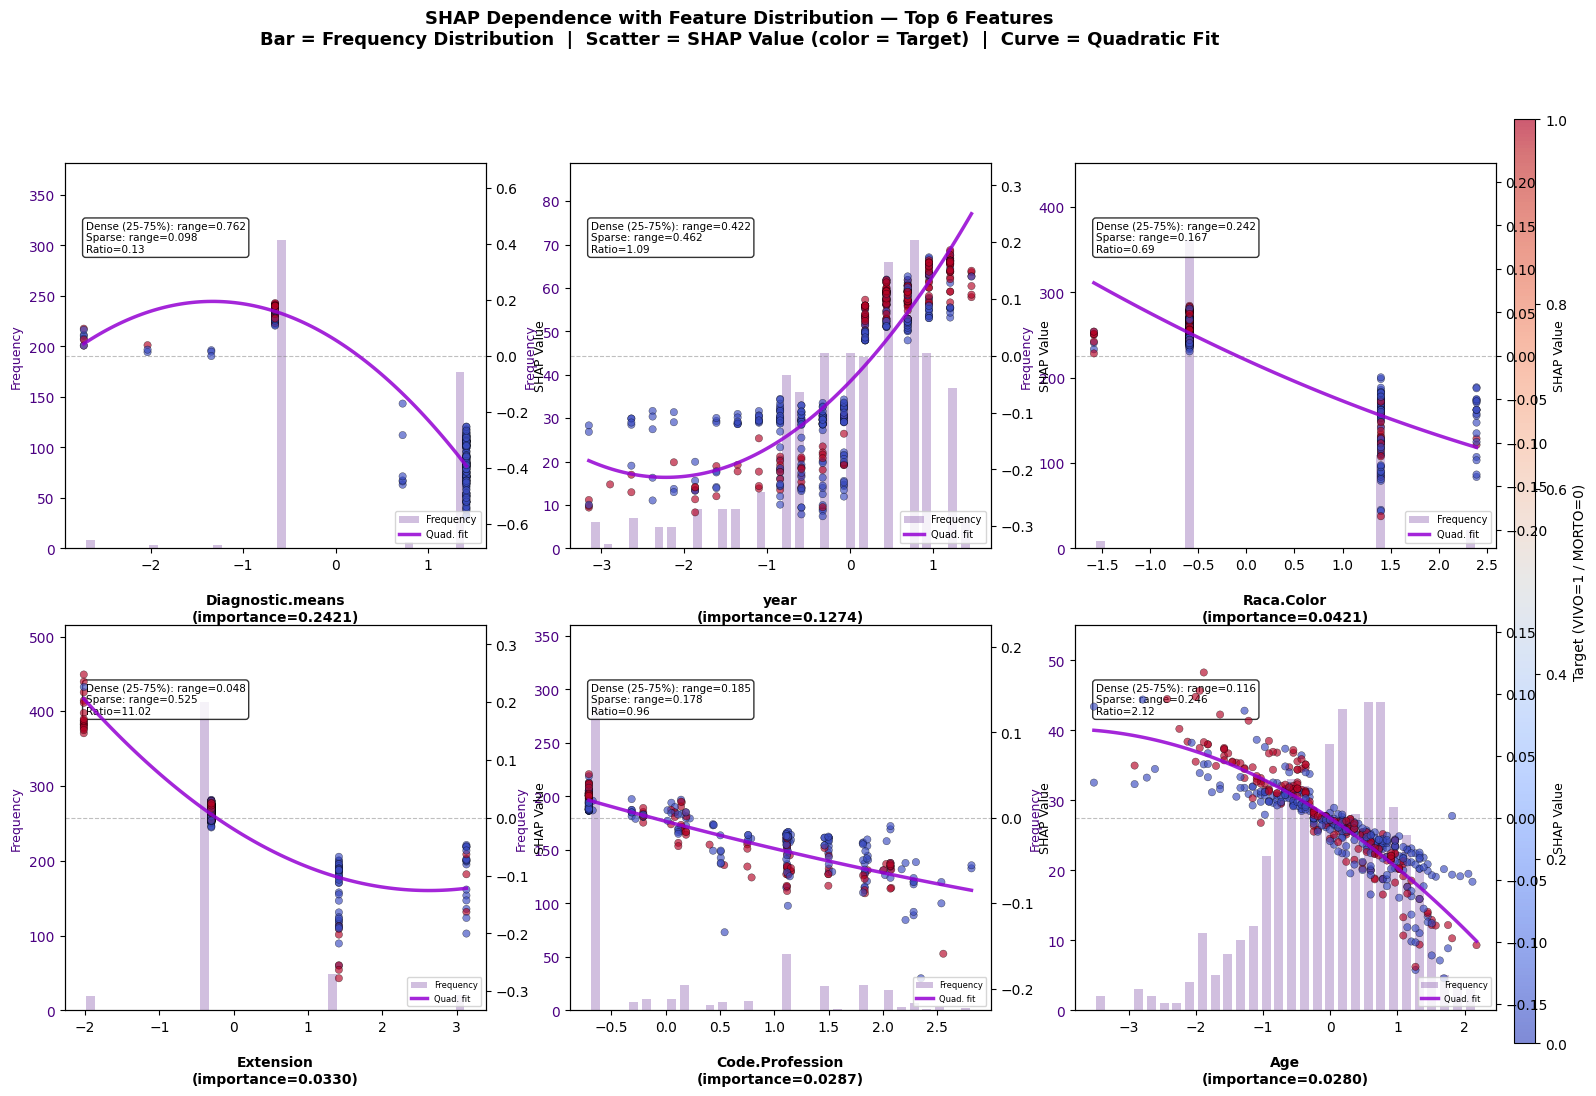

In [6]:
# ============================================================================
# 2. 主图: 带分布的 SHAP 依赖图 (2×3 网格, 双Y轴)
# ============================================================================
print("\n" + "=" * 70)
print("[2] 生成带分布的 SHAP 依赖图 (2×3 网格)")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('SHAP Dependence with Feature Distribution — Top 6 Features\n'
             'Bar = Frequency Distribution  |  Scatter = SHAP Value (color = Target)  |  Curve = Quadratic Fit',
             fontsize=13, fontweight='bold', y=1.02)

results_text = []

for rank, feat_idx in enumerate(top6_idx):
    row, col = divmod(rank, 3)
    ax1 = axes[row, col]          # 主坐标轴: 直方图
    ax2 = ax1.twinx()             # 共享 x 轴: SHAP 散点图

    fn = feature_names[feat_idx]
    x_vals = X_shap[:, feat_idx]
    shap_vals = sv[:, feat_idx]

    # === 左Y轴: 分布直方图 ===
    counts, bin_edges = np.histogram(x_vals, bins=30)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    ax1.bar(bin_centers, counts, width=bin_width * 0.7,
            align='center', color='#4B0082', alpha=0.25, zorder=0,
            label='Frequency')
    ax1.set_ylabel('Frequency', fontsize=9, color='#4B0082')
    ax1.set_ylim(0, counts.max() * 1.25)
    ax1.tick_params(axis='y', labelcolor='#4B0082')

    # === 右Y轴: SHAP 依赖散点图 ===
    scatter = ax2.scatter(
        x_vals, shap_vals,
        c=y_shap, cmap='coolwarm', alpha=0.65, s=28,
        edgecolors='black', linewidth=0.3, zorder=2)

    # 二次多项式拟合
    if len(x_vals) > 10:
        try:
            # 计算 R²
            z2 = np.polyfit(x_vals, shap_vals, 2)
            p2 = np.poly1d(z2)
            x_range = np.linspace(np.min(x_vals), np.max(x_vals), 100)
            y_pred = p2(x_range)

            # R²
            ss_res = np.sum((shap_vals - p2(x_vals))**2)
            ss_tot = np.sum((shap_vals - np.mean(shap_vals))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

            ax2.plot(x_range, y_pred, color='#9400D3',
                     linewidth=2.5, alpha=0.85, zorder=4,
                     label=f'Quad. fit (R²={r2:.3f})')
        except:
            r2 = np.nan
    else:
        r2 = np.nan

    # y=0 参考线
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, zorder=1, alpha=0.5)

    # 计算数据密集区和稀疏区的 SHAP 变化
    dense_mask = x_vals >= np.percentile(x_vals, 25)
    dense_mask &= x_vals <= np.percentile(x_vals, 75)
    sparse_mask = ~dense_mask

    dense_shap_range = np.ptp(shap_vals[dense_mask]) if dense_mask.sum() > 1 else 0
    sparse_shap_range = np.ptp(shap_vals[sparse_mask]) if sparse_mask.sum() > 1 else 0
    range_ratio = sparse_shap_range / (dense_shap_range + 1e-8)

    # 数据密度标注
    ax1.text(0.05, 0.85,
             f'Dense (25-75%): range={dense_shap_range:.3f}\n'
             f'Sparse: range={sparse_shap_range:.3f}\n'
             f'Ratio={range_ratio:.2f}',
             transform=ax1.transAxes, fontsize=7.5, va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
             zorder=5)

    ax2.set_ylabel('SHAP Value', fontsize=9)
    ax1.set_xlabel(f'\n{fn}\n(importance={shap_importance[feat_idx]:.4f})',
                   fontsize=10, fontweight='bold')

    # Y 轴范围
    y_max = np.abs(shap_vals).max() * 1.2
    if y_max > 1e-6:
        ax2.set_ylim(-y_max, y_max)
    else:
        ax2.set_ylim(-1, 1)

    # 图例 (合并 ax1 + ax2)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    offset_font = 6 if rank >= 3 else 7
    ax2.legend(h1 + h2, ['Frequency', 'Quad. fit'],
               loc='lower right', fontsize=offset_font, framealpha=0.8)

    # 图层顺序
    ax1.set_zorder(0)
    ax2.set_zorder(1)
    ax2.patch.set_alpha(0)

    results_text.append({
        'feature': fn,
        'importance': shap_importance[feat_idx],
        'r2': r2,
        'dense_range': dense_shap_range,
        'sparse_range': sparse_shap_range,
        'range_ratio': range_ratio
    })

# 全局颜色条
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.93, 0.08, 0.012, 0.84])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Target (VIVO=1 / MORTO=0)', fontsize=10)

plt.savefig(os.path.join(IMG_DIR, "18a_shap_dependence_with_distribution.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 18a_shap_dependence_with_distribution.png 已保存")

In [7]:
print(f"\n{'Feature':<22} {'Importance':>10} {'R²_quad':>8} {'Dense Range':>12} {'Sparse Range':>13} {'Ratio':>8} {'Risk':>10}")
print(f"{'-'*22} {'-'*10} {'-'*8} {'-'*12} {'-'*13} {'-'*8} {'-'*10}")
for r in results_text:
    risk = "Low" if r['range_ratio'] < 2 else ("Medium" if r['range_ratio'] < 4 else "High")
    print(f"  {r['feature']:<20} {r['importance']:>10.4f} {r['r2']:>8.4f} "
          f"{r['dense_range']:>12.4f} {r['sparse_range']:>13.4f} {r['range_ratio']:>8.2f} {risk:>10}")



Feature                Importance  R²_quad  Dense Range  Sparse Range    Ratio       Risk
---------------------- ---------- -------- ------------ ------------- -------- ----------
  Diagnostic.means         0.2421   0.9518       0.7619        0.0979     0.13        Low
  year                     0.1274   0.7618       0.4222        0.4616     1.09        Low
  Raca.Color               0.0421   0.8042       0.2421        0.1673     0.69        Low
  Extension                0.0330   0.8298       0.0477        0.5252    11.02       High
  Code.Profession          0.0287   0.8028       0.1851        0.1782     0.96        Low
  Age                      0.0280   0.7871       0.1163        0.2462     2.12     Medium
